In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from rdkit import Chem
from rdkit.Chem import AllChem

import tensorflow as tf
import keras_tuner as kt
from tensorflow import keras
from tensorflow.keras import layers

import seaborn as sns # For heatmaps
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

2025-08-13 12:08:02.353313: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-08-13 12:08:02.359255: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-08-13 12:08:02.373590: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1755101282.394833   22384 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1755101282.401314   22384 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1755101282.423307   22384 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

In [2]:
df = pd.read_csv('ChEMBL_amines_12C_morgan_fingerprints.csv')

In [3]:
df

,ChEMBL ID,Name,Molecular Weight,CX Acidic pKa,CX Basic pKa,Aromatic Rings,Molecular Species,Molecular Formula,Smiles,Inchi Key,Amine Class,Morgan_Fingerprint
0,CHEMBL4297305,NB-001,264.33,NaN,10.25,2.0,BASE,C12H20N6O,Nc1ncnc2c1ncn2CCNCCCCCO,CVPTTZZCRDVGSU-UHFFFAOYSA-N,secondary,0000000000000000000001000000000000000000000000...
1,CHEMBL1574,PHENTERMINE,149.24,NaN,10.25,1.0,BASE,C10H15N,CC(C)(N)Cc1ccccc1,DHHVAGZRUROJKS-UHFFFAOYSA-N,primary,0000000000000000000000000000000000000000000000...
2,CHEMBL5394915,NaN,258.32,12.58,8.85,0.0,BASE,C12H22N2O4,COC(=O)[C@@H]1CCCN1C(=O)[C@@H](O)[C@H](N)C(C)C,UCLCHJWFVUTOCB-AEJSXWLSSA-N,primary,0100000000000000000000000000000000000000001000...
3,CHEMBL1546,HYDROXYAMPHETAMINE,151.21,10.48,9.80,1.0,BASE,C9H13NO,CC(N)Cc1ccc(O)cc1,GIKNHHRFLCDOEU-UHFFFAOYSA-N,primary,0100000000000000000000000000000000000000000000...
4,CHEMBL2105671,AFEGOSTAT TARTRATE,297.26,13.52,8.80,0.0,BASE,C10H19NO9,O=C(O)C(O)C(O)C(=O)O.OC[C@H]1CNC[C@@H](O)[C@@H]1O,ULBPPCHRAVUQMC-RWOHWRPJSA-N,secondary,0100000000000000000000000000000000000000000000...
...,...,...,...,...,...,...,...,...,...,...,...,...
5862,CHEMBL684,DIETHYLCARBAMAZINE,199.30,NaN,6.90,0.0,NEUTRAL,C10H21N3O,CCN(CC)C(=O)N1CCN(C)CC1,RCKMWOKWVGPNJF-UHFFFAOYSA-N,tertiary,0000000000000010000000000000000000000000000000...
5863,CHEMBL1086997,LUCERASTAT,219.28,12.90,8.49,0.0,NEUTRAL,C10H21NO4,CCCCN1C[C@H](O)[C@@H](O)[C@@H](O)[C@H]1CO,UQRORFVVSGFNRO-XFWSIPNHSA-N,tertiary,0000000000000000000000000000000000000000000000...
5864,CHEMBL511099,BICIFADINE,173.26,NaN,10.60,1.0,BASE,C12H15N,Cc1ccc(C23CNCC2C3)cc1,OFYVIGTWSQPCLF-UHFFFAOYSA-N,secondary,0000000000000000000000000000000000000000000000...
5865,CHEMBL358040,NORFENEFRINE,153.18,9.56,8.91,1.0,BASE,C8H11NO2,NCC(O)c1cccc(O)c1,LRCXRAABFLIVAI-UHFFFAOYSA-N,primary,0100000000000000000000000000000000000000000000...


In [4]:
print("--- Basic Data Overview ---")
# 1. Count the number of rows
num_rows = df.shape[0]
print(f"Number of rows in the dataset: {num_rows}")

--- Basic Data Overview ---
Number of rows in the dataset: 5867


In [5]:
# 2. Count the number of unique Inchi Keys
num_unique_inchi_keys = df['Inchi Key'].nunique()
print(f"Number of unique Inchi Keys: {num_unique_inchi_keys}")

Number of unique Inchi Keys: 5867


In [6]:
# 3. Range of CX Basic pKa
df['CX Basic pKa'] = pd.to_numeric(df['CX Basic pKa'], errors='coerce')
pka_min = df['CX Basic pKa'].min()
pka_max = df['CX Basic pKa'].max()
print(f"Range of CX Basic pKa: {pka_min:.2f} - {pka_max:.2f}")

Range of CX Basic pKa: 0.65 - 12.89


In [7]:
# 4. Distribution of Amine class (primary, secondary, tertiary)
amine_class_distribution = df['Amine Class'].value_counts(normalize=True) * 100
print("\nPercentage distribution of Amine Class:")
print(amine_class_distribution.round(2))


Percentage distribution of Amine Class:
Amine Class
primary      35.90
secondary    34.04
tertiary     30.07
Name: proportion, dtype: float64


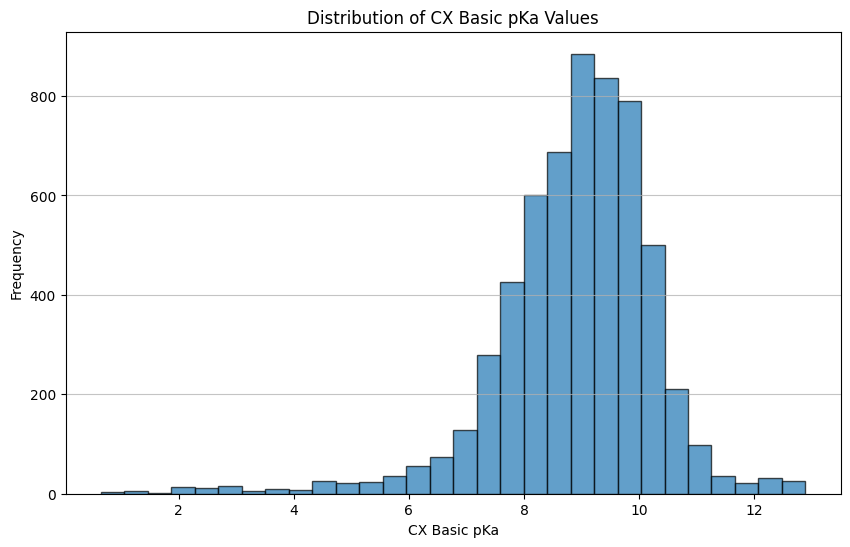

In [8]:
# 5. Histogram of CX Basic pKa values
plt.figure(figsize=(10, 6))
plt.hist(df['CX Basic pKa'].dropna(), bins=30, edgecolor='black', alpha=0.7)
plt.title('Distribution of CX Basic pKa Values')
plt.xlabel('CX Basic pKa')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [9]:
# 6. Missing Values Analysis
print("\nMissing values per column:")
print(df.isnull().sum())


Missing values per column:
ChEMBL ID                0
Name                  5527
Molecular Weight         0
CX Acidic pKa         3974
CX Basic pKa             0
Aromatic Rings           0
Molecular Species        0
Molecular Formula        0
Smiles                   0
Inchi Key                0
Amine Class              0
Morgan_Fingerprint       0
dtype: int64


In [10]:
# 7. Correlation Matrix for numerical features
# Identify numerical columns for correlation
numerical_cols = ['Molecular Weight', 'Aromatic Rings', 'CX Basic pKa']
# Ensure these columns are numeric, coercing errors will turn non-numeric into NaN
for col in numerical_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [11]:
# Drop rows with NaN values in relevant numerical columns for correlation calculation
# Or use .corr(min_periods=1) to include NaNs but it might be less informative
corr_matrix = df[numerical_cols].corr()

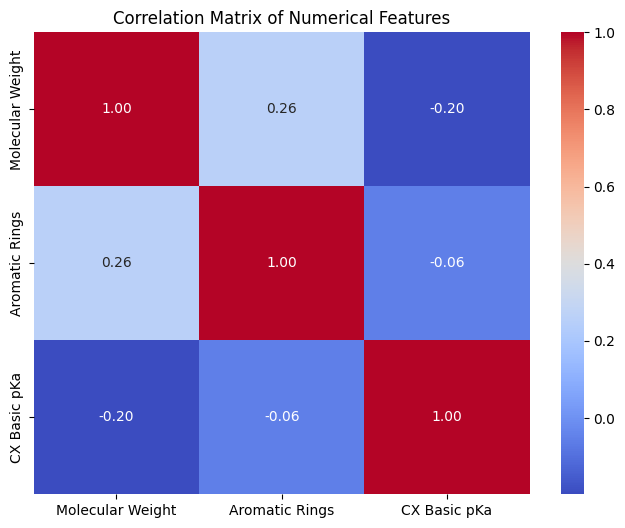

In [12]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

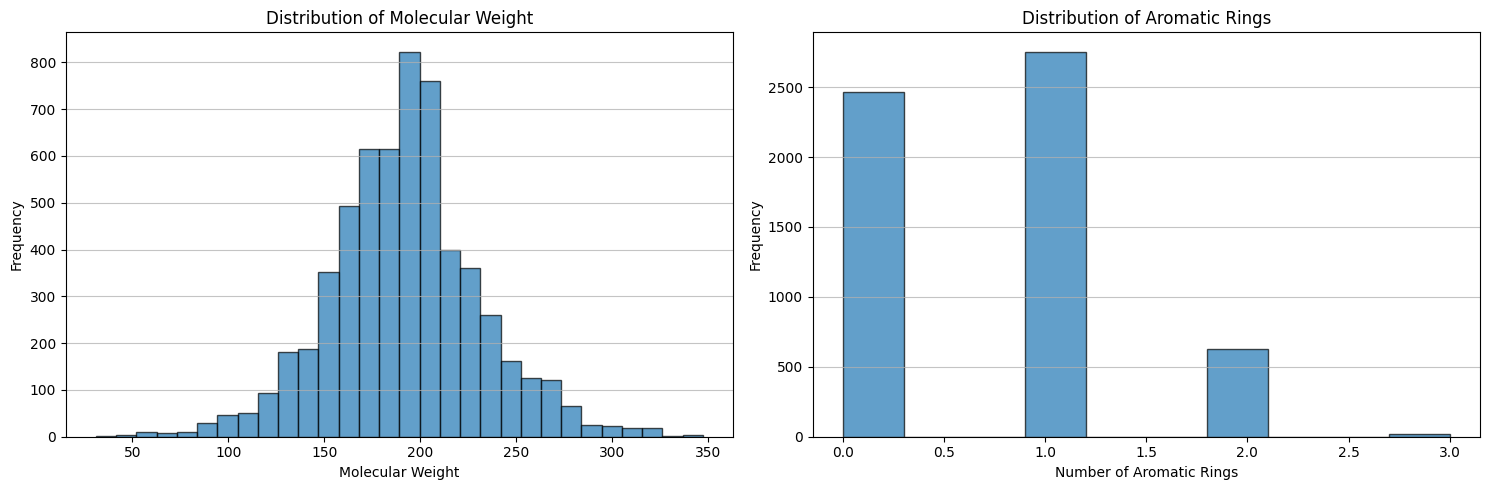

In [13]:
# 8. Visualization of other Feature Distributions (Histograms)
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.hist(df['Molecular Weight'].dropna(), bins=30, edgecolor='black', alpha=0.7)
plt.title('Distribution of Molecular Weight')
plt.xlabel('Molecular Weight')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)

plt.subplot(1, 2, 2)
plt.hist(df['Aromatic Rings'].dropna(), bins=10, edgecolor='black', alpha=0.7)
plt.title('Distribution of Aromatic Rings')
plt.xlabel('Number of Aromatic Rings')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)

plt.tight_layout()
plt.show()

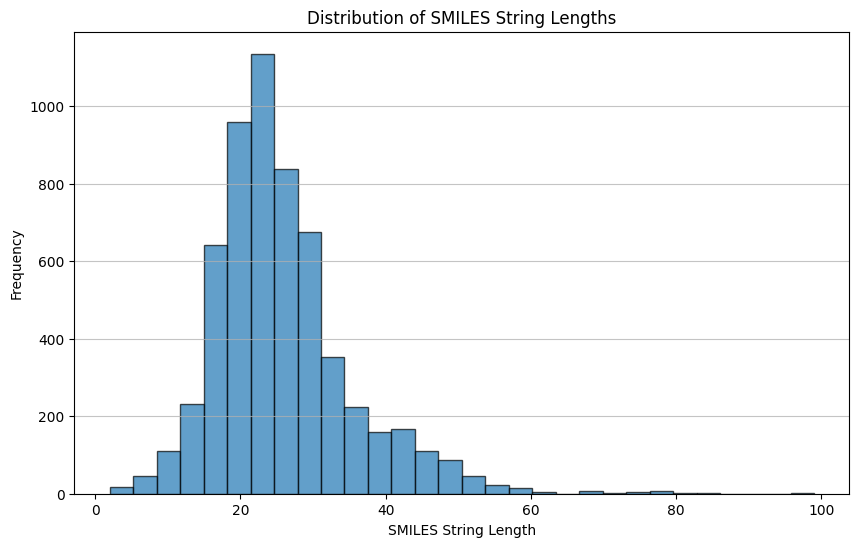

In [14]:
# 9. Length of SMILES Strings Distribution
df['Smiles_Length'] = df['Smiles'].astype(str).apply(len)
plt.figure(figsize=(10, 6))
plt.hist(df['Smiles_Length'], bins=30, edgecolor='black', alpha=0.7)
plt.title('Distribution of SMILES String Lengths')
plt.xlabel('SMILES String Length')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [15]:
# 10. Unique Values for Categorical Features
print("\nUnique values and counts for 'Molecular Species':")
print(df['Molecular Species'].value_counts())

print("\nUnique values and counts for 'Amine Class':")
print(df['Amine Class'].value_counts())


Unique values and counts for 'Molecular Species':
Molecular Species
BASE       3934
NEUTRAL    1922
ACID         11
Name: count, dtype: int64

Unique values and counts for 'Amine Class':
Amine Class
primary      2106
secondary    1997
tertiary     1764
Name: count, dtype: int64


In [16]:
# function to canonicalize a SMILES string
def canonicalize_smiles(smi):
    mol = Chem.MolFromSmiles(smi)
    if mol:
        return Chem.MolToSmiles(mol, canonical=True)
    return None  # or smi if you want to keep the original on failure

# Apply to the 'smiles' column of your DataFrame
df['canonical_smiles'] = df['Smiles'].apply(canonicalize_smiles)

In [17]:
df.describe()

,Molecular Weight,CX Acidic pKa,CX Basic pKa,Aromatic Rings,Smiles_Length
count,5867.000000,1893.000000,5867.000000,5867.000000,5867.000000
mean,191.967505,11.738959,8.887055,0.692688,25.759161
std,39.590318,1.709733,1.382169,0.667408,9.577191
min,31.060000,2.820000,0.650000,0.000000,2.000000
25%,168.200000,10.190000,8.220000,0.000000,20.000000
50%,191.270000,12.400000,9.040000,1.000000,24.000000
75%,215.210000,13.130000,9.750000,1.000000,30.000000
max,347.380000,14.000000,12.890000,3.000000,99.000000


In [18]:
df1 = df[['ChEMBL ID', 'CX Basic pKa', 'canonical_smiles']]

In [19]:
df1.describe()

,CX Basic pKa
count,5867.000000
mean,8.887055
std,1.382169
min,0.650000
25%,8.220000
50%,9.040000
75%,9.750000
max,12.890000


In [20]:
# Convert SMILES to fingerprints
def smiles_to_morgan_fp(smiles, radius=2, n_bits=1024):
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=n_bits)
        return np.array(fp)
    else:
        return np.zeros(n_bits)

In [21]:
df1['fp'] = df1['canonical_smiles'].apply(smiles_to_morgan_fp)
X = np.stack(df1['fp'].values)
y = df1['CX Basic pKa'].values

/tmp/ipykernel_22384/3075979680.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['fp'] = df1['canonical_smiles'].apply(smiles_to_morgan_fp)


In [22]:
# ---------------------------
# Prepare Features and Labels
# ---------------------------
X = pd.DataFrame(df1['fp'].tolist())
y = df1['CX Basic pKa']

In [23]:
# 1. First split: 80% train, 20% (val+test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42)

# 2. Second split: 50% of the remaining 20% → 10% val, 10% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42)

# Output shapes
print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (4693, 1024) (4693,)
Validation: (587, 1024) (587,)
Test: (587, 1024) (587,)


In [24]:
def build_model(hp):
    model = tf.keras.Sequential()
    model.add(layers.Input(shape=(X_train.shape[1],)))

    # Choose number of hidden layers
    for i in range(hp.Int("num_layers", 2, 6)):
        model.add(layers.Dense(
            units=hp.Choice(f"units_{i}", [8, 16, 32, 64, 128, 256, 512]),
            activation=hp.Choice("activation", ["relu", "swish"]),
            kernel_initializer=hp.Choice("kernel_init", ["he_normal", "he_uniform"]),
            bias_initializer=hp.Choice("bias_init", ["zeros", "ones"])
        ))
        model.add(layers.Dropout(hp.Choice(f"dropout_{i}", [0.0, 0.1, 0.2, 0.3, 0.4, 0.5])))

    # Output layer
    model.add(layers.Dense(1))

    # Compile
    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=hp.Choice("lr", [0.01, 0.001, 0.0001])
        ),
        loss="mse",
        metrics=["mae"]
    )
    return model

In [25]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
tuner = kt.BayesianOptimization(
    build_model,
    objective="val_loss",
    max_trials=150,
    directory="tuner_dir",
    project_name="pka_bayes"
)

2025-08-13 12:09:39.114919: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


In [26]:
stop_early = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

tuner.search(X_train, y_train,
             epochs=100,
             validation_data=(X_val, y_val),
             callbacks=[stop_early],
             batch_size=64)

Trial 150 Complete [00h 00m 22s]
val_loss: 0.4093043804168701

Best val_loss So Far: 0.3047938644886017
Total elapsed time: 01h 30m 40s


In [27]:
best_model = tuner.get_best_models(num_models=1)[0]
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]

print("Best hyperparameters:")
for k, v in best_hp.values.items():
    print(f"{k}: {v}")

Best hyperparameters:
num_layers: 2
units_0: 512
activation: swish
kernel_init: he_normal
bias_init: ones
dropout_0: 0.2
units_1: 256
dropout_1: 0.0
lr: 0.001
units_2: 16
dropout_2: 0.2
units_3: 8
dropout_3: 0.2
units_4: 256
dropout_4: 0.4
units_5: 256
dropout_5: 0.2


/home/tkausar/anaconda3/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [28]:
y_pred = best_model.predict(X_test).flatten()
print("Test R2:", r2_score(y_test, y_pred))
print("Test MAE:", mean_absolute_error(y_test, y_pred))
print("Test MSE:", mean_squared_error(y_test, y_pred))

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Test R2: 0.8254024442063788
Test MAE: 0.3426700762467652
Test MSE: 0.37686881318486176


In [29]:
# Predict & evaluate
#best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)
y_mse = mean_squared_error(y_test, y_pred)
y_mae = mean_absolute_error(y_test, y_pred)
y_r2 = r2_score(y_test, y_pred)

y_pred_train = best_model.predict(X_train)
y_mse_train = mean_squared_error(y_train, y_pred_train)
y_mae_train = mean_absolute_error(y_train, y_pred_train)
y_r2_train_ = r2_score(y_train, y_pred_train)

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [30]:
y_pred_val = best_model.predict(X_val)
y_mse_val = mean_squared_error(y_val, y_pred_val)
y_mae_val = mean_absolute_error(y_val, y_pred_val)
y_r2_val_ = r2_score(y_val, y_pred_val)

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


In [32]:
print (y_r2)
print(y_r2_train_)
print(y_r2_val_)

print(y_mae)
print(y_mae_train)
print(y_mae_val)

print(y_mse)
print(y_mse_train)
print(y_mse_val)

0.8254024442063788
0.9923290170221614
0.8340195604139563
0.3426700762467652
0.0845122622478346
0.3363705868696639
0.37686881318486176
0.01448172632301089
0.30479388538054986
